In [2]:
import tensorflow as tf

print('Tensorflow 버전:', tf.__version__)

I0000 00:00:1774495980.876489    3461 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774495981.198836    3461 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774495982.745711    3461 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Tensorflow 버전: 2.21.0


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU 사용 가능! 감지된 GPU: {len(gpus)}개')
    for gpu in gpus:
        print(f'   → {gpu.name}')
else:
    print('⚠️  GPU를 찾을 수 없습니다. CPU로 실행됩니다.')

✅ GPU 사용 가능! 감지된 GPU: 1개
   → /physical_device:GPU:0


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

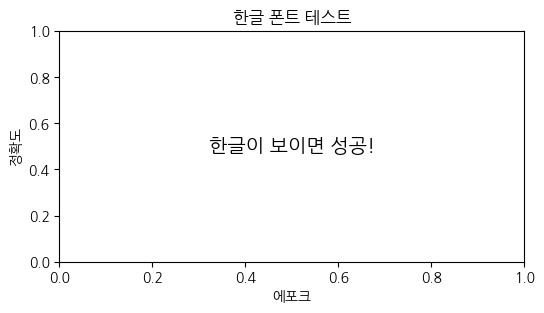

In [10]:
# 한글 테스트
plt.figure(figsize=(6,3))
plt.title('한글 폰트 테스트')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.text(0.5, 0.5, '한글이 보이면 성공!',
         ha='center', va='center', fontsize=14)
plt.show()

In [ ]:
# Ml에서 신경망 모델 생성

In [16]:
from sklearn import datasets
iris = datasets.load_iris()
iris

X_iris = iris.data
y_iris = iris.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris,
                                                    test_size=0.3, random_state=1)

In [28]:
from sklearn.neural_network import MLPClassifier 
mlp = MLPClassifier(hidden_layer_sizes=(50,30), activation='logistic', 
                     solver='adam', max_iter=1000)
mlp.fit(X_train, y_train)
mlp.fit(X_train, y_train)
mlp.score(X_test, y_test)
pred = mlp.predict(X_test)

import pandas as pd
import numpy as np
pd.crosstab(pred, y_test)

col_0,0,1,2
row_0,,,
0,14,0,0
1,0,18,0
2,0,0,13


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential()

model.add(Input(shape=(4,)))
model.add(Dense(50, activation="sigmoid"))
model.add(Dense(30, activation="sigmoid"))
model.add(Dense(3, activation="softmax"))

In [35]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

#model.history

In [36]:
model.fit(X_train, y_train, epochs=300, verbose=1)

Epoch 1/300


I0000 00:00:1774504860.879115   28608 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15000__.13


1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9688 - loss: 0.1571

I0000 00:00:1774504861.576986   28605 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15000__.13


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.9714 - loss: 0.1401
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9714 - loss: 0.1358 
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9810 - loss: 0.1343 
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.1310 
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.1295 
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.1278 
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.1257 
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.1269 
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.1262 
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9810 - loss: 0.1230 
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.1214 
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9714 - loss: 0.1210 


In [37]:
model.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step - accuracy: 1.0000 - loss: 0.0255


[0.025493929162621498, 1.0]

In [38]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 50)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            93 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,621 (21.96 KB)

 Trainable params: 1,873 (7.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,748 (14.64 KB)